# Metacell — decoder side: X_state vs AE, single-cell vs metacell (+ UMAP)

`pancellflow` kernel (decoders = jax/scaleflow). Loads the dual-centroid metacells (X_state + AE_128)
and decodes them. **DEGs are called with `scanpy.tl.rank_genes_groups` (Wilcoxon)** — drugs vs control,
per cell line. Four conditions, all scored against the true (real ptb − real ctrl) delta on the called
DEGs (control-subtracted, control decoded the same way as perturbed so the decoder offset cancels):

| condition | perturbed representation | decoder |
|---|---|---|
| **x_state** | per-cell (decode each cell, avg) | `dec_X_state_opt` |
| **x_ae** | per-cell (decode each cell, avg) | `AE_128_opt` |
| **state_metacell** | size-wt decode of X_state centroids | `dec_X_state_opt` |
| **ae_metacell** | size-wt decode of AE_128 centroids | `AE_128_opt` |

`x_*` = per-cell ceiling (needs the cells); `*_metacell` = deployment (predicted metacell is a mean).

In [1]:
import sys, pickle, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, anndata as ad, h5py, scanpy as sc
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
sys.path.insert(0, "/lustre/groups/ml01/workspace/xiaotong.fu/pancellflow/sub/src")
from scaleflow.model._recon import ReconDecoder
BASE = "/lustre/groups/ml01/workspace/xiaotong.fu/pancellflow"
PADJ, LFC, MIN_PTB, MIN_DEG = 0.05, 0.25, 20, 10

## 0. Load decoders, data, dual-centroid metacells; decode all cells (both latents)

In [2]:
dec_xs = ReconDecoder.load(f"{BASE}/recon_weights/dec_X_state_opt/ReconDecoder.pkl")
dec_ae = ReconDecoder.load(f"{BASE}/recon_weights/AE_128_opt/ReconDecoder.pkl")
pm = pickle.load(open(f"{BASE}/outputs/metacell/decode_inputs_dual.pkl", "rb"))
cmc = pickle.load(open(f"{BASE}/outputs/metacell/control_metacells_dual.pkl", "rb"))
A = ad.read_h5ad(f"{BASE}/outputs/metacell/sciplex_all_for_metacell.h5ad")
genes = np.asarray(A.X.todense(), np.float32) if hasattr(A.X, "todense") else np.asarray(A.X, np.float32)
var_names = A.var_names.to_numpy()
Xst = np.asarray(A.obsm["X_state"], np.float32)
with h5py.File(f"{BASE}/recon_weights/sciplex3_with_emb.h5ad", "r") as f:
    AE = f["obsm"]["AE_128_opt"][:].astype(np.float32)
cl = A.obs["cell_line"].astype(str).to_numpy(); drug = A.obs["drug"].astype(str).to_numpy()
ctrl = A.obs["control"].to_numpy().astype(bool); split = A.obs["split"].astype(str).to_numpy()
pert = ~ctrl; LINES = sorted(set(cl)); drug_split = {d: split[pert & (drug == d)][0] for d in np.unique(drug[pert])}

print("decoding all cells (both latents) …")
dg = {"X_state": np.asarray(dec_xs.decode(Xst), np.float32), "AE": np.asarray(dec_ae.decode(AE), np.float32)}
dmc = {"X_state": np.asarray(dec_xs.decode(np.asarray(pm["mc_xstate"], np.float32)), np.float32),
       "AE":      np.asarray(dec_ae.decode(np.asarray(pm["mc_ae"], np.float32)), np.float32)}
real_ctrl = {c: genes[ctrl & (cl == c)].mean(0) for c in LINES}
sc_ctrl = {P: {c: dg[P][ctrl & (cl == c)].mean(0) for c in LINES} for P in ("X_state", "AE")}
mc_ctrl = {"X_state": {c: np.average(np.asarray(dec_xs.decode(cmc[c]["xstate"]), np.float32), axis=0, weights=cmc[c]["size"]) for c in LINES},
           "AE":      {c: np.average(np.asarray(dec_ae.decode(cmc[c]["ae"]), np.float32), axis=0, weights=cmc[c]["size"]) for c in LINES}}
print("done.")

decoding all cells (both latents) …


done.


## 1. DEGs via scanpy `rank_genes_groups` (Wilcoxon), then 4-condition comparison

Per cell line: `rank_genes_groups(groups=test_drugs, reference='control', method='wilcoxon')`. A gene is
a DEG for a drug if `pvals_adj < 0.05` AND `|mean log-norm Δ| ≥ 0.25`. On those DEGs we score the four
decoded deltas (magnitude R², sign-concordance, recall) vs the true delta. Median over a line's test
conditions (≥20 ptb cells & ≥10 DEGs).

In [3]:
def wilcoxon_padj(c):
    # rank_genes_groups (Wilcoxon) for line c: each test drug vs control -> per-gene padj
    tdr = [d for d in np.unique(drug[pert & (cl == c)]) if drug_split[d] == "test"]
    msk = (cl == c) & (ctrl | np.isin(drug, tdr))
    grp = np.where(ctrl[msk], "control", drug[msk]).astype(object)
    sub = ad.AnnData(genes[msk].copy(), obs=pd.DataFrame({"group": pd.Categorical(grp)}, index=np.arange(int(msk.sum())).astype(str)))
    sub.var_names = var_names; sub.uns["log1p"] = {"base": None}
    sc.tl.rank_genes_groups(sub, "group", groups=list(tdr), reference="control", method="wilcoxon")
    out = {}
    for d in tdr:
        r = sc.get.rank_genes_groups_df(sub, group=d)
        out[d] = np.nan_to_num(r.set_index("names")["pvals_adj"].reindex(var_names).values, nan=1.0)
    return out

def degm(t, m, sig):  # magnitude R2 on DEGs, sign-concordance, recall
    topd = set(np.argsort(-np.abs(m))[:int(sig.sum())]); ts = set(np.where(sig)[0])
    return float(r2_score(t[sig], m[sig])), float(np.mean(np.sign(t[sig]) == np.sign(m[sig]))), len(ts & topd) / len(ts)

print("calling DEGs (Wilcoxon) per line …")
padj = {c: wilcoxon_padj(c) for c in LINES}
CONDS = ["x_state", "x_ae", "state_metacell", "ae_metacell"]
rows = []
for c in LINES:
    for d in [d for d in padj[c] if drug_split[d] == "test"]:
        m = pert & (cl == c) & (drug == d)
        if m.sum() < MIN_PTB:
            continue
        true_md = genes[m].mean(0) - real_ctrl[c]
        sig = (padj[c][d] < PADJ) & (np.abs(true_md) >= LFC)
        if sig.sum() < MIN_DEG:
            continue
        sel = (pm["mc"]["cell_line"].values == c) & (pm["mc"]["drug"].values == d)
        if not sel.any():
            continue
        w = pm["mc"]["size"].values[sel]
        deltas = {
            "x_state":        dg["X_state"][m].mean(0) - sc_ctrl["X_state"][c],
            "x_ae":           dg["AE"][m].mean(0) - sc_ctrl["AE"][c],
            "state_metacell": np.average(dmc["X_state"][sel], axis=0, weights=w) - mc_ctrl["X_state"][c],
            "ae_metacell":    np.average(dmc["AE"][sel], axis=0, weights=w) - mc_ctrl["AE"][c],
        }
        r = dict(cell_line=c, n_deg=int(sig.sum()))
        for name, dd in deltas.items():
            r[f"{name}_degR2"], r[f"{name}_sign"], r[f"{name}_recall"] = degm(true_md, dd, sig)
        rows.append(r)
df = pd.DataFrame(rows); df.to_csv(f"{BASE}/outputs/metacell/decoded_4way_wilcoxon.csv", index=False)
summ = df.groupby("cell_line").median(numeric_only=True).round(3); summ["n_cond"] = df.groupby("cell_line").size()
print("magnitude R2 on Wilcoxon DEGs (median over test conditions):")
summ[["n_cond", "n_deg"] + [f"{c}_degR2" for c in CONDS] + [f"{c}_recall" for c in CONDS]]

calling DEGs (Wilcoxon) per line …


magnitude R2 on Wilcoxon DEGs (median over test conditions):


,n_cond,n_deg,x_state_degR2,x_ae_degR2,state_metacell_degR2,ae_metacell_degR2,x_state_recall,x_ae_recall,state_metacell_recall,ae_metacell_recall
cell_line,,,,,,,,,,
A549,11,18.0,0.951,0.978,0.940,0.959,0.846,0.895,0.804,0.889
K-562,4,20.0,0.844,0.913,0.803,0.888,0.718,0.825,0.743,0.791
MCF7,3,37.0,0.959,0.978,0.950,0.979,0.914,0.914,0.892,0.892


## 2. Bar chart — DEG magnitude R² across the 4 conditions, per line

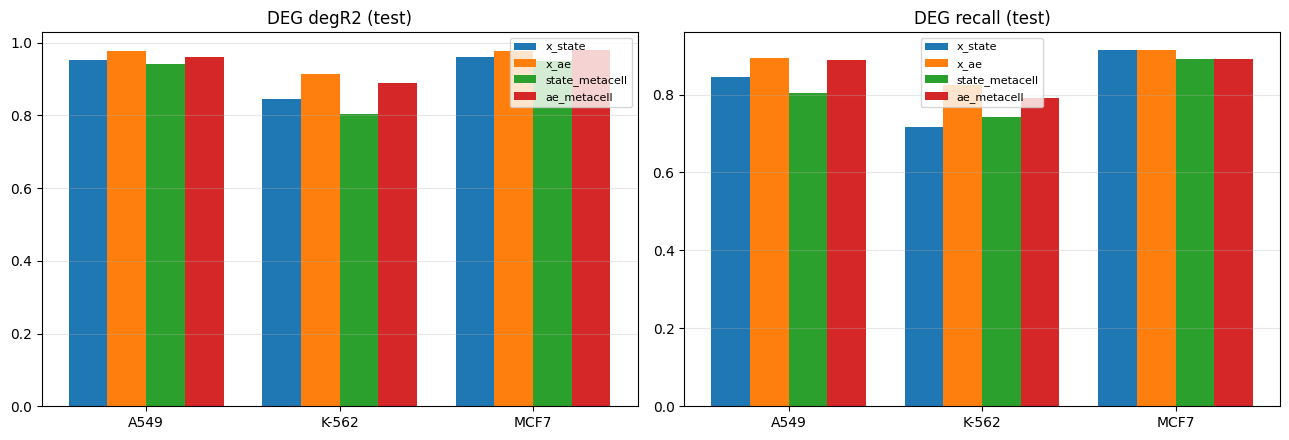

In [4]:
x = np.arange(len(LINES)); w = 0.2
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for j, met in enumerate(["degR2", "recall"]):
    for i, cond in enumerate(CONDS):
        ax[j].bar(x + (i - 1.5) * w, [summ.loc[c, f"{cond}_{met}"] for c in LINES], w, label=cond)
    ax[j].set_xticks(x); ax[j].set_xticklabels(LINES); ax[j].set_title(f"DEG {met} (test)")
    ax[j].grid(alpha=.3, axis="y"); ax[j].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 3. UMAP sanity — true vs decoded vs decoded-metacell (X_state pipeline)

Shared gene-space UMAP for a strong-response A549 test drug. Decoded cells should track true clouds;
decoded **metacells sit at the centres** of their ctrl/ptb clouds; ctrl→ptb shift consistent.

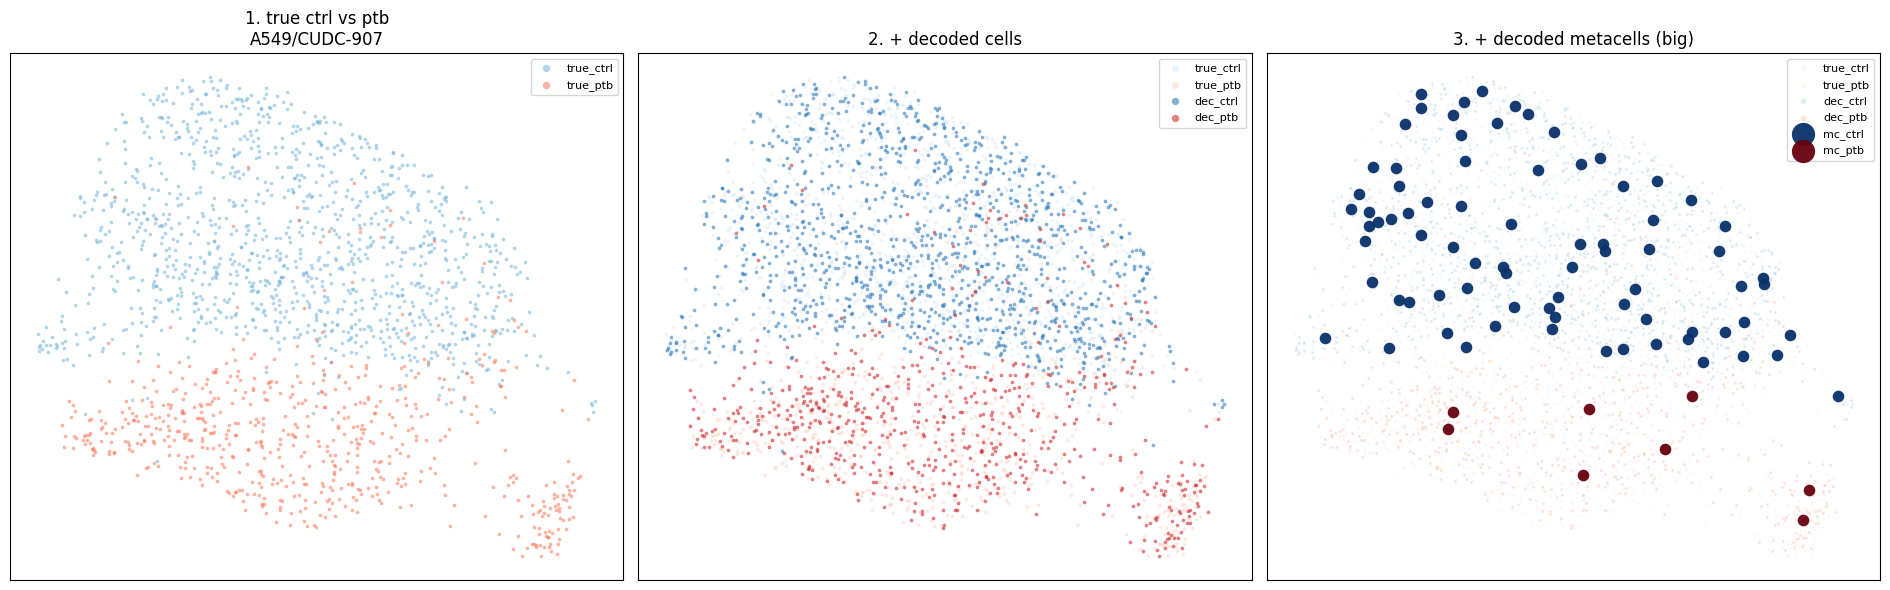

In [5]:
c = "A549"
tdr = [d for d in np.unique(drug[pert & (cl == c)]) if drug_split[d] == "test"]
d = max(tdr, key=lambda d: np.linalg.norm(genes[pert & (cl == c) & (drug == d)].mean(0) - real_ctrl[c]))
rng = np.random.default_rng(0)
ci = rng.choice(np.where(ctrl & (cl == c))[0], min(1200, int((ctrl & (cl == c)).sum())), replace=False)
pi = rng.choice(np.where(pert & (cl == c) & (drug == d))[0], min(1200, int((pert & (cl == c) & (drug == d)).sum())), replace=False)
selp = (pm["mc"]["cell_line"].values == c) & (pm["mc"]["drug"].values == d)
blocks = [("true_ctrl", genes[ci]), ("true_ptb", genes[pi]), ("dec_ctrl", dg["X_state"][ci]), ("dec_ptb", dg["X_state"][pi]),
          ("mc_ctrl", np.asarray(dec_xs.decode(cmc[c]["xstate"]), np.float32)), ("mc_ptb", dmc["X_state"][selp])]
grp = np.concatenate([[k] * len(v) for k, v in blocks]); Z = np.vstack([v for _, v in blocks]).astype(np.float32)
e = ad.AnnData(Z); sc.pp.pca(e, n_comps=50); sc.pp.neighbors(e, n_neighbors=15); sc.tl.umap(e); U = e.obsm["X_umap"]
def s(ax, keys, sz, col, al):
    for k, ss, cc, aa in zip(keys, sz, col, al):
        mm = grp == k; ax.scatter(U[mm, 0], U[mm, 1], s=ss, c=cc, alpha=aa, label=k, linewidths=0)
    ax.set_xticks([]); ax.set_yticks([]); ax.legend(fontsize=8, markerscale=2)
fig, ax = plt.subplots(1, 3, figsize=(19, 6))
s(ax[0], ["true_ctrl", "true_ptb"], [7, 7], ["#6baed6", "#fb6a4a"], [.5, .5]); ax[0].set_title(f"1. true ctrl vs ptb\n{c}/{d[:24]}")
s(ax[1], ["true_ctrl", "true_ptb", "dec_ctrl", "dec_ptb"], [7, 7, 7, 7], ["#c6dbef", "#fcbba1", "#2171b5", "#cb181d"], [.3, .3, .55, .55]); ax[1].set_title("2. + decoded cells")
s(ax[2], ["true_ctrl", "true_ptb", "dec_ctrl", "dec_ptb"], [4, 4, 4, 4], ["#deebf7", "#fee0d2", "#9ecae1", "#fcae91"], [.25, .25, .35, .35])
s(ax[2], ["mc_ctrl", "mc_ptb"], [70, 70], ["#08306b", "#67000d"], [.95, .95]); ax[2].set_title("3. + decoded metacells (big)")
plt.tight_layout(); plt.show()

## 4. Interpretation

*(after run)* Compare the four conditions on `degR2`: `x_state`/`x_ae` are the per-cell ceilings;
`state_metacell`/`ae_metacell` are the deployment numbers. Within a decoder, metacell vs per-cell = the
decode-of-mean cost; X_state vs AE = which decoder preserves DEG magnitudes better (now under the
standard Wilcoxon DEG set). The UMAP confirms decoded metacells land at the cloud centres (no wiring bug).